---
title: "Pruning phenotypes in PanUKB"
author: "Saikat Banerjee"
format:
  html: default
date: "2024-12-12"
file-modified: "2024-12-12"
abstract: "We want to filter a few phenotypes to study the loadings of the factors. In order to prune the phenotypes, we calculate the correlation matrix of all phenotypes."

---

In [1]:
import os
import numpy as np
import pandas as pd
import pickle
import re

import matplotlib
import matplotlib.pyplot as plt
from pymir import mpl_stylesheet
from pymir import mpl_utils

mpl_stylesheet.banskt_presentation(splinecolor = 'black', dpi = 120)

In [2]:
data_dir = "/gpfs/commons/home/sbanerjee/work/npd/PanUKB/data"
result_dir = "/gpfs/commons/home/sbanerjee/npddata/panukb/results/colormann-svd"

zscore_df = pd.read_pickle(os.path.join(data_dir, f"modselect/zscore_noRx.pkl"))
trait_df  = pd.read_pickle(os.path.join(data_dir, f"modselect/traits_all_with_desc.pkl"))
trait_df  = trait_df.query('trait_type != "prescriptions"')

method = 'nnm-sparse'
method_resdir = os.path.join(result_dir, method, "noRx")
with (open(f"{method_resdir}/mf_comps_k200.pkl", "rb")) as fh:
    loadings, factors, cos2_pheno, cos2_variant, \
    contribution_pheno, contribution_variant = pickle.load(fh)
with (open(f"{method_resdir}/pca_comps.pkl", "rb")) as fh:
    U, S, V = pickle.load(fh)
with (open(f"{method_resdir}/sparseX.pkl", "rb")) as fh:
    sparseM = pickle.load(fh)


X = np.array(zscore_df.values.T)
X_cent = X - np.mean(X, axis = 0, keepdims = True)

res_filename = os.path.join(method_resdir, "nnm_sparse_model_r155872_iter1000.pkl")
with (open(res_filename, "rb")) as fh:
    lowrank_model = pickle.load(fh)
lowX = lowrank_model['X_']
lowX_cent = lowX - np.mean(lowX, axis = 0, keepdims = True)
lowX_std = lowX_cent / np.sqrt(np.prod(lowX_cent.shape))

print ("Nuclear Norms")
print (f"Low rank model: {np.linalg.norm(lowX, ord = 'nuc'):.3f}")
print (f"Input data: {np.linalg.norm(X, ord = 'nuc'):.3f}")
print (f"Input data (mean centered): {np.linalg.norm(X_cent, ord = 'nuc'):.3f}")

Nuclear Norms
Low rank model: 106525.779
Input data: 431988.255
Input data (mean centered): 431234.720


In [3]:
X.shape

(2110, 51368)

In [18]:
X_corr = np.corrcoef(X)

In [21]:
X_cent_corr = np.corrcoef(X_cent)

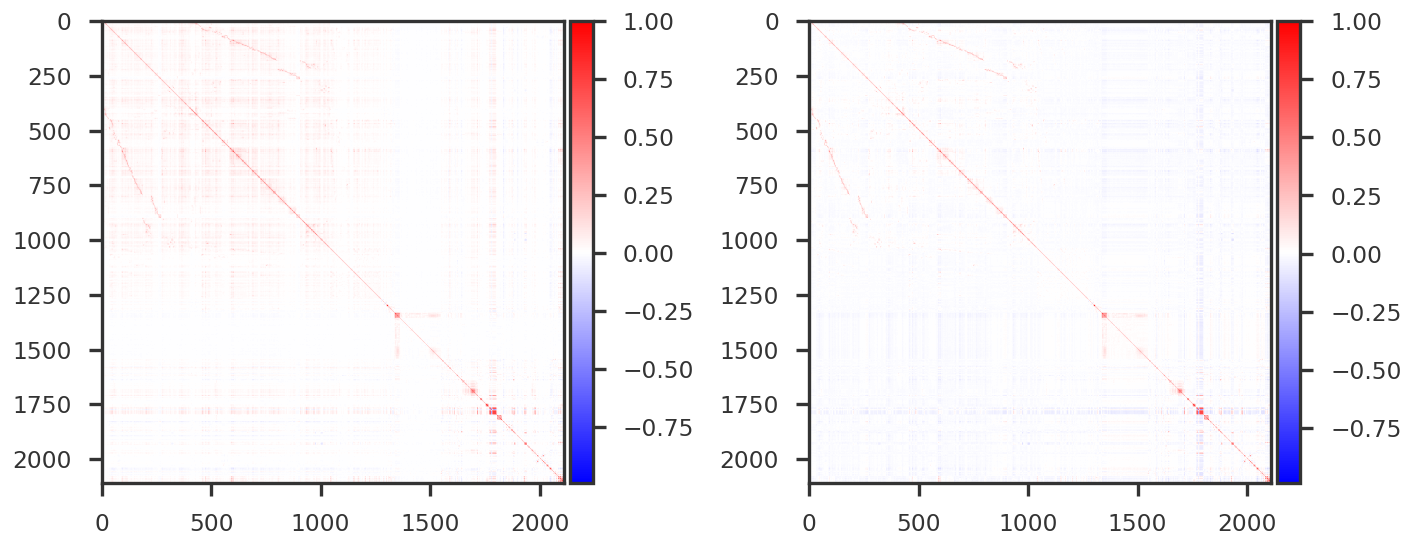

In [26]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
from sklearn.preprocessing import normalize as sk_normalize

fig = plt.figure(figsize = (12, 6))
ax1 = fig.add_subplot(1,2,1)
ax2 = fig.add_subplot(1,2,2)
divider1 = make_axes_locatable(ax1)
divider2 = make_axes_locatable(ax2)
cax1 = divider1.append_axes('right', size='5%', pad=0.05)
cax2 = divider2.append_axes('right', size='5%', pad=0.05)

im1 = ax1.imshow(X_corr, cmap='bwr')
fig.colorbar(im1, cax = cax1, orientation='vertical')

im2 = ax2.imshow(X_cent_corr, cmap='bwr')
fig.colorbar(im2, cax = cax2, orientation='vertical')

# Show the plot
plt.tight_layout()
plt.show()

In [57]:
X_corr_sq = np.square(X_corr)
X_cent_corr_sq = np.square(X_cent_corr)

npair = int((X.shape[0] * (X.shape[0] - 1)) / 2)
xvals = np.zeros(npair)
yvals = np.zeros(npair)
k = 0
for i in range(X.shape[0]):
    for j in range(i+1, X.shape[0]):
        xvals[k] = X_corr_sq[i,j]
        yvals[k] = X_cent_corr_sq[i,j]
        k += 1

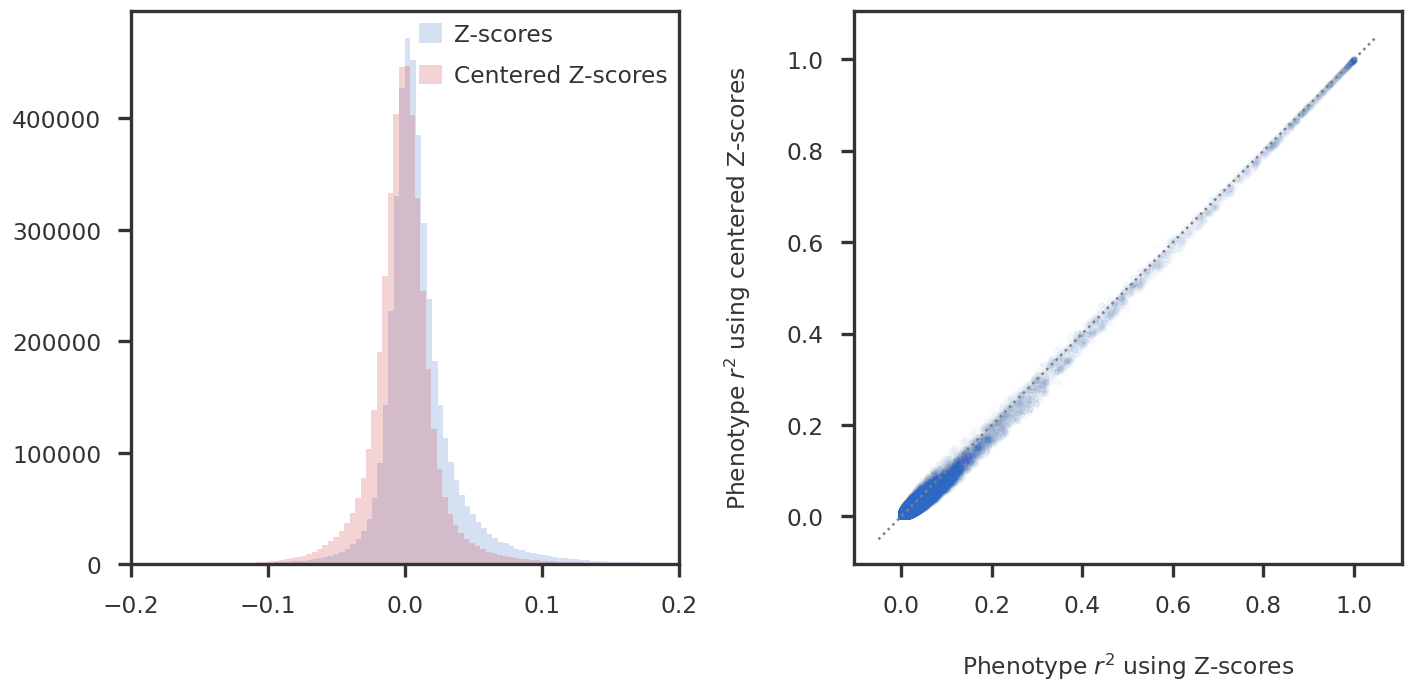

In [59]:
fig = plt.figure(figsize = (12,6))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.hist(X_corr.flatten(), bins = 500, alpha = 0.2, edgecolor='None', label = "Z-scores")
ax1.hist(X_cent_corr.flatten(), bins = 500, alpha = 0.2, edgecolor='None', label = "Centered Z-scores")
ax1.set_xlim(-0.2, 0.2)
ax1.legend()

ax2.scatter(xvals, yvals, alpha = 0.01, s = 10)
ax2.set_xlabel(r"Phenotype $r^2$ using Z-scores")
ax2.set_ylabel(r"Phenotype $r^2$ using centered Z-scores")
mpl_utils.plot_diag(ax2)

plt.tight_layout()
plt.show()

In [127]:
llm_methods = [
    "ls-da3m0ns/bge_large_medical",
    "medicalai/ClinicalBERT",
    "emilyalsentzer/Bio_ClinicalBERT",
]

llm_ctypes = [
    "community", 
    "kmeans", 
    "agglomerative"]

llm_outdir = "/gpfs/commons/home/sbanerjee/work/npd/PanUKB/results/llm"

llm_clusters = {method : { x : None for x in llm_ctypes } for method in llm_methods}
for method in llm_methods:
    for ctype in llm_ctypes:
        m_filename = os.path.join(llm_outdir, f"{method}/{ctype}_clusters.pkl")
        with open(m_filename, "rb") as fh:
            llm_clusters[method][ctype] = pickle.load(fh)
            
def get_llm_cluster_labels(trait_idx, llm_cluster):
    clusteridx = np.full([trait_idx.shape[0],], -1)
    for i, ccomps in enumerate(llm_cluster):
        for idx in ccomps:
            if idx in trait_idx:
                clusteridx[np.where(trait_idx == idx)] = i
    return clusteridx

In [128]:
llm_method = "ls-da3m0ns/bge_large_medical"
llm_ctype = "agglomerative"
data_labels = get_llm_cluster_labels(trait_df.index.to_numpy(), 
                                    llm_clusters[llm_method][llm_ctype])
llm_categories = {
    1: "Sleep, speech, lifestyle and environment",
    2: "Cardiovascular system and hematologic disorders",
    3: "Reproductive health and related disorders",
    4: "Diabetes and lipid metabolism",
    5: "Body composition, BMI, obesity and nutrition",
    6: "Gastrointestinal disorders and related conditions",
    7: "Respiratory disorders and infectious diseases",
    8: "Neurological and musculoskeletal conditions",
    9: "Medical examinations, follow-ups, and family history",
    10: "Medications and allergies",
    11: "Vision and refractive metrics",
    12: "Ear, nose, throat, and dental health",
    13: "Toxicology and supplemental medications",
    14: "Dietary intake",
    15: "Respiratory disorders and associated medications",
    16: "Hematological metrics",
    17: "Urinary system disorders",
    18: "Alcohol consumption and related behavior",
    19: "Demographics and life events",
    20: "Ocular health",
    21: "Self-reported health issues",
    22: "Skin disorders and infections",
    23: "Tobacco use and exposure",
    24: "Blood pressure metrics",
    25: "Carotid intima-media thickness (IMT)",
    26: "Neoplasms and cancers",
    27: "Metabolic and nutritional disorders",
    28: "Thyroid-related conditions",
    29: "Injuries and trauma",
    30: "Mental health and emotional well-being"}

In [141]:
trait_h2 = np.array([max(1e-6, x) for x in trait_df['estimates.final.h2_observed'].fillna(1e-6).tolist()])
pidx_sorted = np.argsort(trait_h2)[::-1]

ntarget = 50
r2_thres = np.square(0.065)
ipheno = list()

# force_exclude = [
#     "Nap during day",
#     "Fluid intelligence questions attempted",
#     "Night shift length",
#     "Getting up in morning",
#     "Length of menstrual cycle",
#     "Getting up in morning",
#     "Year immigrated to UK",
#     "psychotic",
#     "Number of jobs held",
#     " intake"
# ]

category_exclude = [1, 10, 13, 14, 19, 30]

pidx_sorted = np.argsort(trait_h2)[::-1]
for i in pidx_sorted:
    do_skip = list()
    do_skip = [X_cent_corr_sq[i, j] > r2_thres for j in ipheno]
    # do_skip += [x in trait_df.iloc[i]['short_description'] for x in force_exclude]
    do_skip.append(data_labels[i] + 1 in category_exclude)
    if not any(do_skip):
        ipheno.append(i)
    if len(ipheno) >= ntarget:
        break

In [142]:
# for i in np.argsort(X_cent_corr_sq[1976, :])[::-1]:
for i in ipheno:
    print (f"\t{trait_h2[i]}\t{X_cent_corr_sq[1976,i]:6.4f}\t{trait_df.iloc[i]['short_description']}\t{llm_categories[data_labels[i] + 1]}")

	0.588	1.0000	Standing height	Body composition, BMI, obesity and nutrition
	0.309	0.0000	Abdominal adipose tissue volume	Body composition, BMI, obesity and nutrition
	0.281	0.0009	Mean platelet (thrombocyte) volume	Hematological metrics
	0.278	0.0007	Impedance of whole body	Body composition, BMI, obesity and nutrition
	0.239	0.0007	Carotid IMT mean at 210°	Carotid intima-media thickness (IMT)
	0.232	0.0033	IOP, Goldmann-correlated (left)	Vision and refractive metrics
	0.214	0.0028	Red blood cell (erythrocyte) count	Hematological metrics
	0.196	0.0000	Eosinophill percentage	Hematological metrics
	0.17	0.0000	Age DVT diagnosed	Cardiovascular system and hematologic disorders
	0.16	0.0033	Pulse rate (during BP measurement)	Cardiovascular system and hematologic disorders
	0.119	0.0005	Urea	Metabolic and nutritional disorders
	0.114	0.0016	6mm asymmetry angle (left)	Vision and refractive metrics
	0.0939	0.0003	Average monthly spirits intake	Alcohol consumption and related behavior
	0.0867	0.

In [135]:
max(data_labels)

29

In [107]:
trait_df.iloc[1979]['short_description']

'Spherical power (left)'

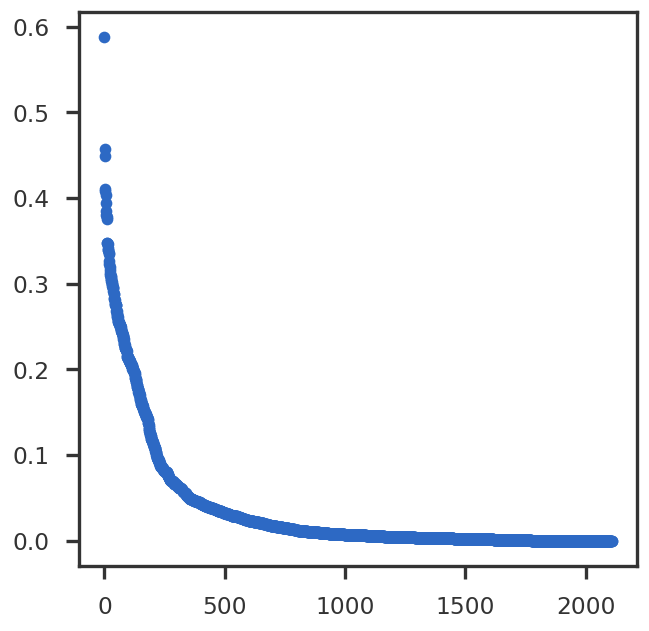

In [68]:
fig = plt.figure(figsize = (6,6))
ax1 = fig.add_subplot(111)

ax1.scatter(np.arange(trait_h2.shape[0]), trait_h2[np.argsort(trait_h2)[::-1]])

plt.show()

In [70]:
np.where(trait_h2 > 0.01)[0].shape

(875,)

In [15]:
np.mean(rndmX, axis = 0, keepdims = True).shape

(1, 100)

In [17]:
loadings.shape

(2110, 200)